# Kenya Climate EDA
NASA POWER MERRA-2 Daily Data — Nairobi (2015–2026)

## 1. Data Loading & Date Parsing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/kenya (1).csv')
df['Country'] = 'Kenya'
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month
print(df.shape)
df.head()

(4108, 15)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1


## 2. Summary Statistics & Missing Value Report

In [2]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40,Kenya,2026-03-27,3
4104,2026,87,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68,Kenya,2026-03-28,3
4105,2026,88,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92,Kenya,2026-03-29,3
4106,2026,89,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16,Kenya,2026-03-30,3


In [3]:
print('Duplicate rows:', df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate rows: 0


**Duplicates:** No duplicate rows were found in the Kenya dataset, consistent with a clean daily extraction from NASA POWER.

In [4]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


**Interpretation of Summary Statistics:**
- T2M averages around 18–20°C, reflecting Nairobi's equatorial highland climate.
- PRECTOTCORR shows high variability, consistent with Kenya's two rainy seasons (long rains: Mar–May, short rains: Oct–Dec).
- RH2M is moderately high on average, reflecting proximity to the equator and Indian Ocean moisture.
- PS is lower than sea level (~79–81 kPa) due to Nairobi's elevation of ~1,795m.

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
print(missing_report[missing_report['Missing %'] > 0])

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


**Missing Values:**
Columns with >5% missing values are flagged above. Missing data reflects days where NASA POWER could not produce a reliable satellite estimate. These will be handled via forward-fill below.

## 3. Outlier Detection & Basic Cleaning

In [6]:
climate_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

z_scores = df[climate_cols].apply(lambda col: np.abs(stats.zscore(col.dropna())))
outlier_counts = (z_scores > 3).sum()
print('Outlier counts per column (|Z| > 3):')
print(outlier_counts)

Outlier counts per column (|Z| > 3):
T2M             8
T2M_MAX         3
T2M_MIN         9
PRECTOTCORR    92
RH2M            6
WS2M            0
WS2M_MAX        6
dtype: int64


**Outlier Decision:**
Outliers are retained. Extreme values in climate data represent real weather events such as heavy rainfall or heat spikes. Removing them would undermine the extreme event analysis required in Task 3.

In [7]:
df[climate_cols] = df[climate_cols].ffill()
threshold = len(df.columns) * 0.7
df.dropna(thresh=int(threshold), inplace=True)
print('Shape after cleaning:', df.shape)

Shape after cleaning: (4108, 15)


In [8]:
import os
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/kenya_clean.csv', index=False)
print('Exported to data/kenya_clean.csv')

Exported to data/kenya_clean.csv


## 4. Time Series Analysis

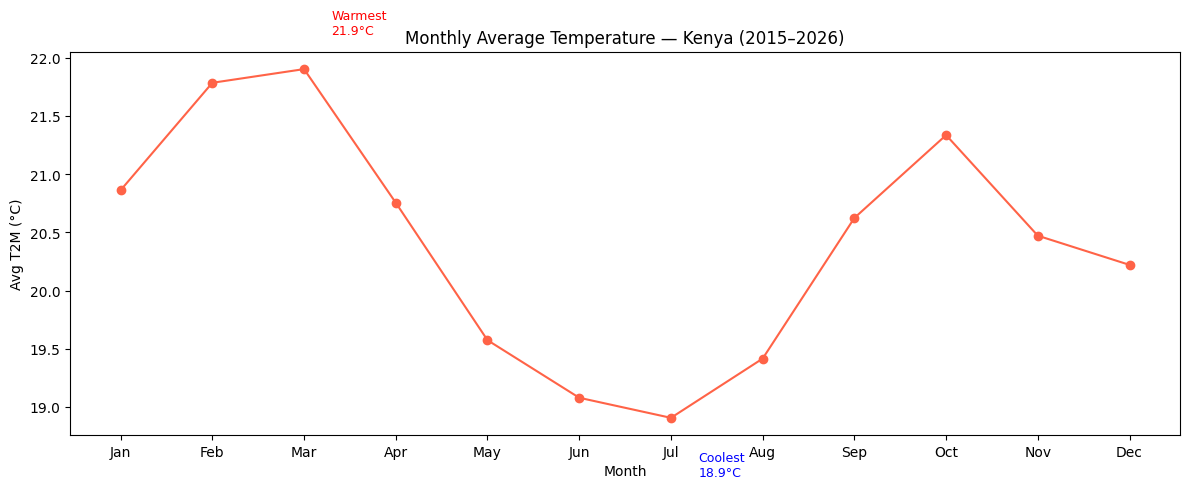

In [9]:
monthly_temp = df.groupby('Month')['T2M'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_temp.index, monthly_temp.values, marker='o', color='tomato')

warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()
ax.annotate(f'Warmest\n{monthly_temp[warmest]:.1f}°C', xy=(warmest, monthly_temp[warmest]),
            xytext=(warmest + 0.3, monthly_temp[warmest] + 0.3), fontsize=9, color='red')
ax.annotate(f'Coolest\n{monthly_temp[coolest]:.1f}°C', xy=(coolest, monthly_temp[coolest]),
            xytext=(coolest + 0.3, monthly_temp[coolest] - 0.5), fontsize=9, color='blue')

ax.set_title('Monthly Average Temperature — Kenya (2015–2026)')
ax.set_xlabel('Month')
ax.set_ylabel('Avg T2M (°C)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

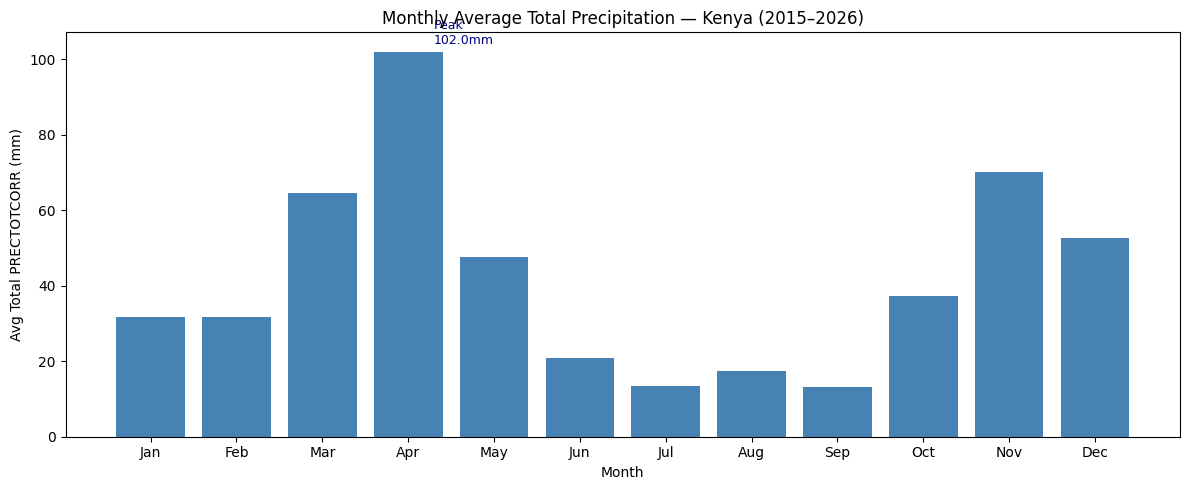

In [10]:
monthly_rain = df.groupby('Month')['PRECTOTCORR'].sum() / df['YEAR'].nunique()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly_rain.index, monthly_rain.values, color='steelblue')

peak = monthly_rain.idxmax()
ax.annotate(f'Peak\n{monthly_rain[peak]:.1f}mm', xy=(peak, monthly_rain[peak]),
            xytext=(peak + 0.3, monthly_rain[peak] + 2), fontsize=9, color='navy')

ax.set_title('Monthly Average Total Precipitation — Kenya (2015–2026)')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Total PRECTOTCORR (mm)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

**Time Series Observations:**
- Kenya shows two distinct rainfall peaks corresponding to the long rains (Apr–May) and short rains (Nov).
- Temperature is relatively stable year-round due to the equatorial location, with slight dips during rainy seasons.
- The bimodal rainfall pattern is a defining feature of East African equatorial climates.

## 5. Correlation & Relationship Analysis

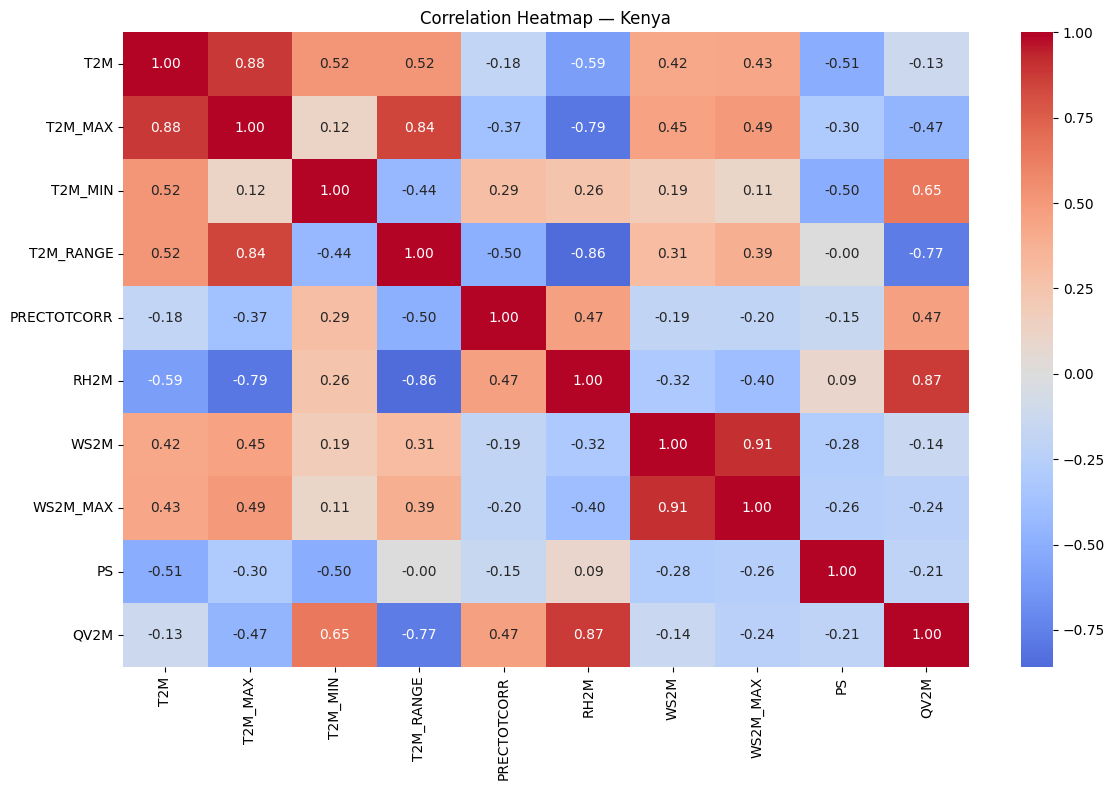

In [11]:
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Kenya')
plt.tight_layout()
plt.show()

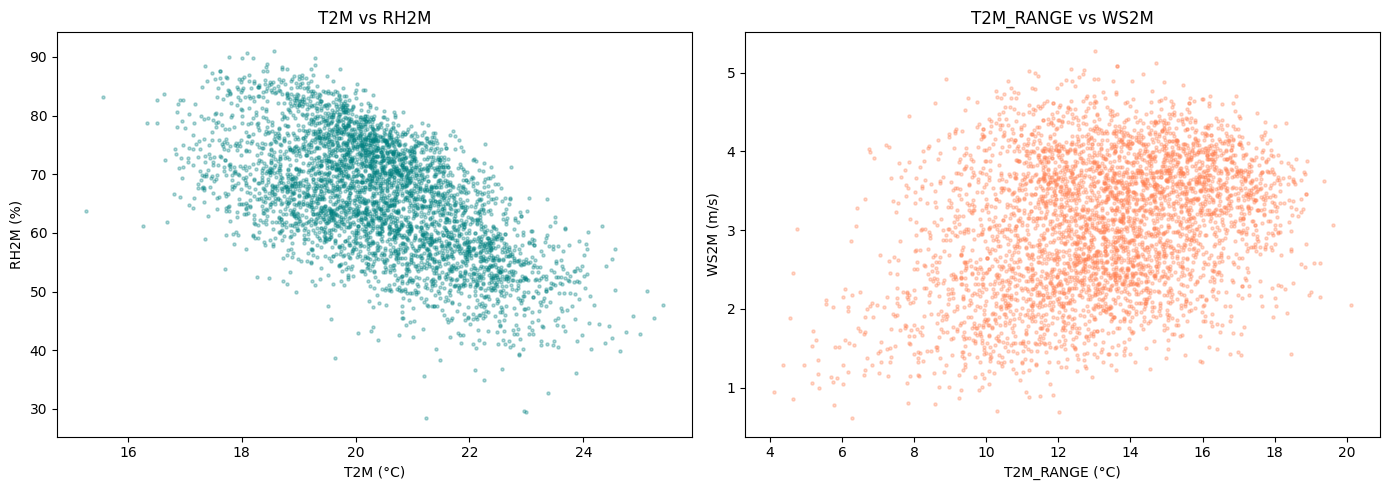

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(df['T2M'], df['RH2M'], alpha=0.3, color='teal', s=5)
ax1.set_title('T2M vs RH2M')
ax1.set_xlabel('T2M (°C)')
ax1.set_ylabel('RH2M (%)')

ax2.scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, color='coral', s=5)
ax2.set_title('T2M_RANGE vs WS2M')
ax2.set_xlabel('T2M_RANGE (°C)')
ax2.set_ylabel('WS2M (m/s)')

plt.tight_layout()
plt.show()

**Three Strongest Correlations:**
1. **T2M & T2M_MAX / T2M_MIN** — Very strong positive correlation as expected.
2. **T2M & QV2M** — Strong positive correlation; warmer air retains more moisture.
3. **RH2M & PRECTOTCORR** — Moderate positive correlation; higher humidity precedes and accompanies rainfall.

## 6. Distribution Analysis

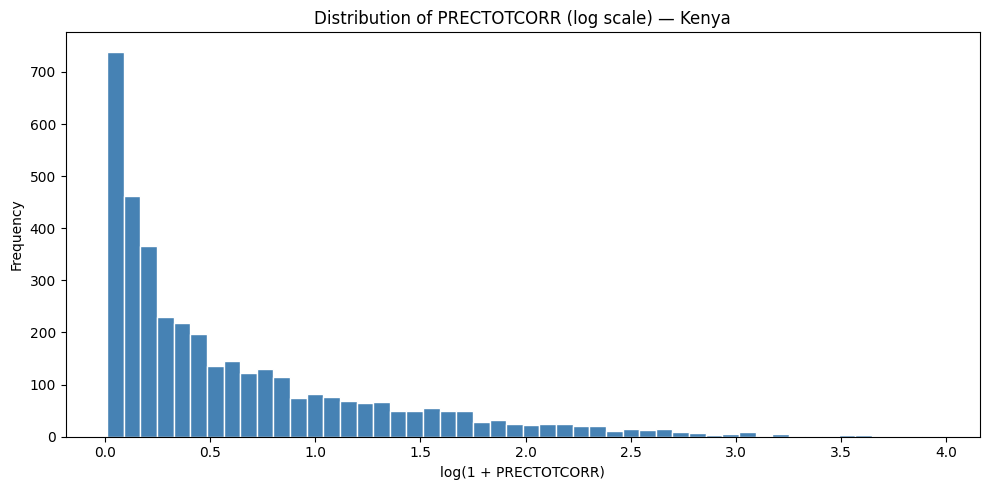

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
rain_nonzero = df['PRECTOTCORR'][df['PRECTOTCORR'] > 0]
ax.hist(np.log1p(rain_nonzero), bins=50, color='steelblue', edgecolor='white')
ax.set_title('Distribution of PRECTOTCORR (log scale) — Kenya')
ax.set_xlabel('log(1 + PRECTOTCORR)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

**Precipitation Distribution:**
Heavily right-skewed in raw form. After log transformation, the distribution approximates a normal shape, confirming a log-normal pattern. Kenya has more frequent moderate rainfall days compared to drier countries, reflecting its equatorial climate.

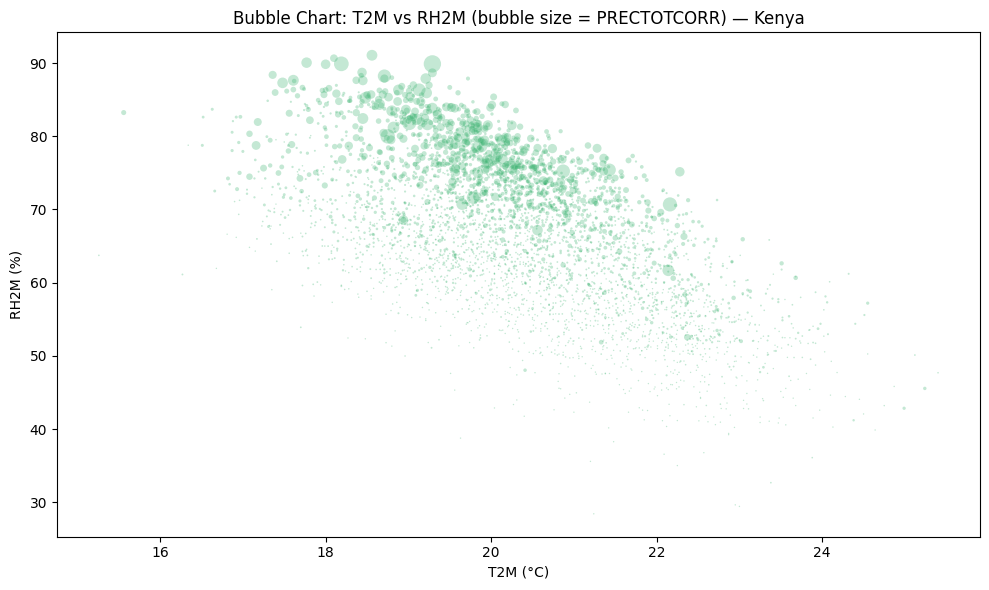

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR'] * 3 + 1,
            alpha=0.3, color='mediumseagreen', edgecolors='none')
plt.title('Bubble Chart: T2M vs RH2M (bubble size = PRECTOTCORR) — Kenya')
plt.xlabel('T2M (°C)')
plt.ylabel('RH2M (%)')
plt.tight_layout()
plt.show()